## AI-Powered Spam Email Detection System using NLP


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Data

In [2]:
df = pd.read_csv(r"C:\Users\ankit\Desktop\ML\emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Data Cleaning

In [3]:
df['text'] = df['text'].fillna("")
df = df.dropna(subset=['spam'])
df = df.drop_duplicates()

def basic_clean(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text'] = df['text'].apply(basic_clean)
df = df[df['text'].str.strip() != ""]
df['spam'] = df['spam'].astype(int)

print(df.shape)

(5695, 2)


## Feature Engineering

In [4]:
df['length'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(x.split()))

## NLP Preprocessing

In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)

## Train-Test Split

In [6]:
X = df[['clean_text', 'length', 'num_words']]
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Custom Transformers

In [7]:
class TextSelector(BaseEstimator):
    def fit(self, X, y=None): return self
    def transform(self, X): return X['clean_text']

class NumericSelector(BaseEstimator):
    def fit(self, X, y=None): return self
    def transform(self, X): return X[['length','num_words']]

## Pipeline

In [8]:
pipeline = Pipeline([
    ('features', FeatureUnion([
        ('text', Pipeline([
            ('selector', TextSelector()),
            ('tfidf', TfidfVectorizer(max_features=5000))
        ])),
        ('num', Pipeline([
            ('selector', NumericSelector()),
            ('scaler', StandardScaler())
        ]))
    ])),
    ('model', LogisticRegression(max_iter=1000))
])

## Train Model

In [9]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('text',
                                                 Pipeline(steps=[('selector',
                                                                  TextSelector()),
                                                                 ('tfidf',
                                                                  TfidfVectorizer(max_features=5000))])),
                                                ('num',
                                                 Pipeline(steps=[('selector',
                                                                  NumericSelector()),
                                                                 ('scaler',
                                                                  StandardScaler())]))])),
                ('model', LogisticRegression(max_iter=1000))])

## Evaluation

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       872
           1       0.98      0.93      0.95       267

    accuracy                           0.98      1139
   macro avg       0.98      0.96      0.97      1139
weighted avg       0.98      0.98      0.98      1139



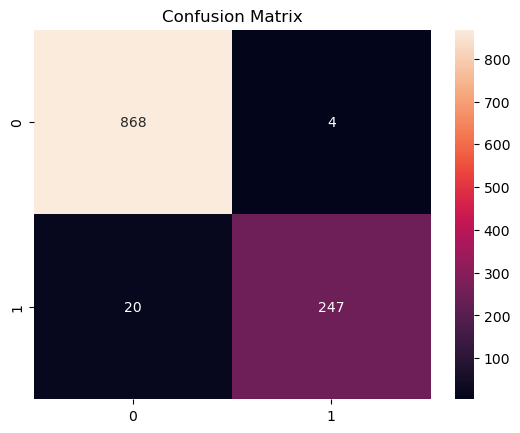

In [10]:
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Save Model

In [12]:
joblib.dump(pipeline, "spam_model.pkl")

['spam_model.pkl']

## Prediction Function

In [14]:
def predict_email(text):
    model = joblib.load("spam_model.pkl")
    
    data = pd.DataFrame({
        'clean_text':[preprocess(text)],
        'length':[len(text)],
        'num_words':[len(text.split())]
    })
    
    result = model.predict(data)[0]
    return "Spam" if result == 1 else "Not Spam"

## Test Prediction

In [15]:
predict_email("Congratulations! You won a free iPhone")

'Not Spam'

## Confidence Prediction

In [16]:
def predict_with_confidence(text):
    model = joblib.load("spam_model.pkl")
    
    data = pd.DataFrame({
        'clean_text':[preprocess(text)],
        'length':[len(text)],
        'num_words':[len(text.split())]
    })
    
    prob = model.predict_proba(data)[0][1]
    label = "Spam" if prob > 0.5 else "Not Spam"
    
    return label, round(prob*100, 2)

predict_with_confidence("Win money now!!!")

('Spam', 70.99)

## Batch Prediction

In [17]:
emails = [
    "Win cash prize now!!!",
    "Meeting at 10 AM tomorrow",
    "Limited offer buy now",
    "Project deadline extended"
]

for mail in emails:
    print(mail, "->", predict_email(mail))

Win cash prize now!!! -> Not Spam
Meeting at 10 AM tomorrow -> Not Spam
Limited offer buy now -> Spam
Project deadline extended -> Not Spam


## Live Input (Optional)

In [ ]:
while True:
    text = input("Enter Email (exit to stop): ")
    
    if text.lower() == "exit":
        break
        
    print(predict_email(text))